# Website Traffic Analysis

This project analyzes website traffic data to understand event activity, traffic trends, geographic distribution, and content performance. The analysis uses Python to identify meaningful patterns and provide data-driven recommendations for improving website engagement.

## Objectives

- Analyze website event types and traffic trends.
- Identify high-activity countries and cities.
- Analyze content, artist, and track performance.
- Measure available engagement patterns.
- Provide actionable business recommendations.

**Tools:** Python, Jupyter Notebook, Pandas, NumPy, Matplotlib

##  Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 60)

print("Libraries imported successfully!")

Libraries imported successfully!


##  Loading the Dataset

In [2]:
df = pd.read_csv("traffic.csv")

print("Dataset loaded successfully!")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully!
Rows: 226,278
Columns: 9


In [3]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

print("\nData Types:")
display(df.dtypes)

Dataset Shape: (226278, 9)

Column Names:
['event', 'date', 'country', 'city', 'artist', 'album', 'track', 'isrc', 'linkid']

First 5 Rows:


,event,date,country,city,artist,album,track,isrc,linkid
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
1,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
2,click,2021-08-21,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores Más,No Llores Más,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd
4,click,2021-08-21,Maldives,Malé,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8



Data Types:


event      object
date       object
country    object
city       object
artist     object
album      object
track      object
isrc       object
linkid     object
dtype: object

## Data Quality Check

In [4]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (df.isnull().mean() * 100).round(2)
})

print("Missing Values:")
display(missing)

duplicate_count = df.duplicated().sum()

print(f"Exact Duplicate Rows: {duplicate_count:,}")
print(f"Duplicate Percentage: {duplicate_count / len(df) * 100:.2f}%")

print("\nDate Range:")
print("Start:", df["date"].min())
print("End:", df["date"].max())

print("\nUnique Event Types:")
print(df["event"].unique())

Missing Values:


,Missing Values,Missing Percentage
event,0,0.00
date,0,0.00
country,11,0.00
city,11,0.00
artist,37,0.02
album,5,0.00
track,5,0.00
isrc,7121,3.15
linkid,0,0.00


Exact Duplicate Rows: 103,711
Duplicate Percentage: 45.83%

Date Range:
Start: 2021-08-19
End: 2021-08-25

Unique Event Types:
['click' 'preview' 'pageview']


##  Data Cleaning

The data is cleaned by converting dates to datetime format, standardizing text values, and handling missing categorical values. Exact duplicate rows are retained because the available data does not provide enough information to determine whether repeated records represent genuine repeated events.

In [5]:
# Convert date column
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Clean text columns
text_columns = [
    "event", "country", "city",
    "artist", "album", "track",
    "isrc", "linkid"
]

for col in text_columns:
    df[col] = df[col].astype("string").str.strip()

# Standardize event names
df["event"] = df["event"].str.lower()

# Handle missing categorical values
categorical_columns = [
    "country", "city", "artist",
    "album", "track", "isrc"
]

for col in categorical_columns:
    df[col] = df[col].fillna("Unknown")

print("Data cleaning completed.")
print("Invalid dates:", df["date"].isna().sum())
print("Remaining missing values:", df.isna().sum().sum())

Data cleaning completed.
Invalid dates: 0
Remaining missing values: 0


In [6]:
summary = pd.DataFrame({
    "Metric": [
        "Total Events",
        "Total Columns",
        "Unique Countries",
        "Unique Cities",
        "Unique Artists",
        "Unique Tracks",
        "Unique Links",
        "Start Date",
        "End Date"
    ],
    "Value": [
        len(df),
        len(df.columns),
        df["country"].nunique(),
        df["city"].nunique(),
        df["artist"].nunique(),
        df["track"].nunique(),
        df["linkid"].nunique(),
        df["date"].min().date(),
        df["date"].max().date()
    ]
})

display(summary)

,Metric,Value
0,Total Events,226278
1,Total Columns,9
2,Unique Countries,212
3,Unique Cities,11993
4,Unique Artists,2420
5,Unique Tracks,3563
6,Unique Links,3839
7,Start Date,2021-08-19
8,End Date,2021-08-25


##  Exploratory Data Analysis (EDA)

##  Event Analysis

The dataset contains three types of recorded website activity: pageviews, clicks, and previews. Their distribution helps us understand the overall interaction pattern.

In [7]:
event_summary = (
    df["event"]
    .value_counts()
    .rename_axis("Event")
    .reset_index(name="Count")
)

event_summary["Percentage"] = (
    event_summary["Count"] / len(df) * 100
).round(2)

display(event_summary)

# Event-level engagement
total_events = len(df)
clicks = (df["event"] == "click").sum()
previews = (df["event"] == "preview").sum()

engagement_rate = (clicks + previews) / total_events

print(f"Event-Level Engagement Rate: {engagement_rate:.2%}")

,Event,Count,Percentage
0,pageview,142015,62.76
1,click,55732,24.63
2,preview,28531,12.61


Event-Level Engagement Rate: 37.24%


### Event Distribution

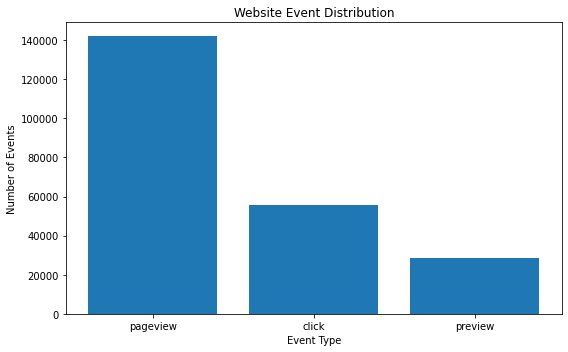

In [21]:
plt.figure(figsize=(8, 5))

plt.bar(
    event_summary["Event"],
    event_summary["Count"]
)

plt.title("Website Event Distribution")
plt.xlabel("Event Type")
plt.ylabel("Number of Events")
plt.tight_layout()
plt.show()

##  Daily Traffic Analysis

Daily traffic analysis helps identify changes in website activity during the seven-day period covered by the dataset.

In [9]:
daily_summary = (
    df.groupby(["date", "event"])
    .size()
    .unstack(fill_value=0)
)

daily_summary["Total Events"] = daily_summary.sum(axis=1)

display(daily_summary)

peak_day = daily_summary["Total Events"].idxmax()
lowest_day = daily_summary["Total Events"].idxmin()

print(
    f"Peak Traffic: {peak_day.date()} "
    f"({daily_summary.loc[peak_day, 'Total Events']:,} events)"
)

print(
    f"Lowest Traffic: {lowest_day.date()} "
    f"({daily_summary.loc[lowest_day, 'Total Events']:,} events)"
)

event,click,pageview,preview,Total Events
date,,,,
2021-08-19,9207,22366,3788,35361
2021-08-20,8508,21382,4222,34112
2021-08-21,8071,21349,4663,34083
2021-08-22,7854,20430,4349,32633
2021-08-23,7315,18646,3847,29808
2021-08-24,7301,18693,3840,29834
2021-08-25,7476,19149,3822,30447


Peak Traffic: 2021-08-19 (35,361 events)
Lowest Traffic: 2021-08-23 (29,808 events)


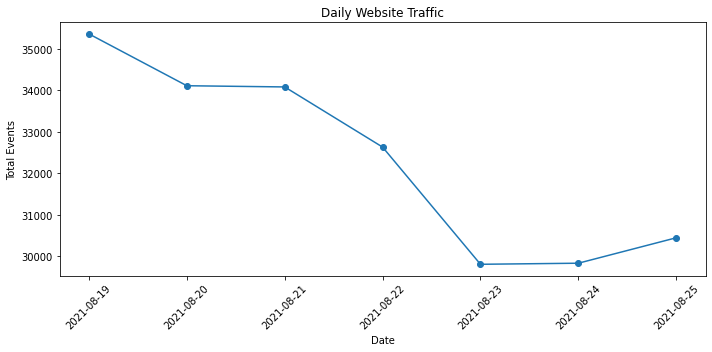

In [22]:
plt.figure(figsize=(10, 5))

plt.plot(
    daily_summary.index,
    daily_summary["Total Events"],
    marker="o"
)

plt.title("Daily Website Traffic")
plt.xlabel("Date")
plt.ylabel("Total Events")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##  Geographic Analysis

This section identifies the countries and cities generating the highest recorded activity. These represent event counts rather than unique users because the dataset does not contain user IDs.

In [11]:
country_summary = (
    df.groupby("country")
    .agg(
        Total_Events=("event", "size"),
        Pageviews=("event", lambda x: (x == "pageview").sum()),
        Clicks=("event", lambda x: (x == "click").sum()),
        Previews=("event", lambda x: (x == "preview").sum())
    )
    .sort_values("Total_Events", ascending=False)
)

print("Top 10 Countries:")
display(country_summary.head(10))

city_summary = (
    df.groupby("city")
    .size()
    .sort_values(ascending=False)
)

print("Top 10 Cities:")
display(city_summary.head(10).to_frame("Total Events"))

Top 10 Countries:


,Total_Events,Pageviews,Clicks,Previews
country,,,,
Saudi Arabia,47334,28873,9495,8966
India,42992,27286,11609,4097
United States,32558,20839,9533,2186
France,15661,9674,4054,1933
Iraq,8260,4897,1836,1527
United Kingdom,5970,3845,1517,608
Pakistan,5644,3212,1653,779
Germany,4794,3141,1225,428
United Arab Emirates,3702,2335,766,601


Top 10 Cities:


,Total Events
city,
Jeddah,22791
Riyadh,17454
Unknown,16672
Hyderabad,3682
Dammam,3276
Erbil,3105
Kuwait City,3010
Lucknow,2808
Muscat,2717


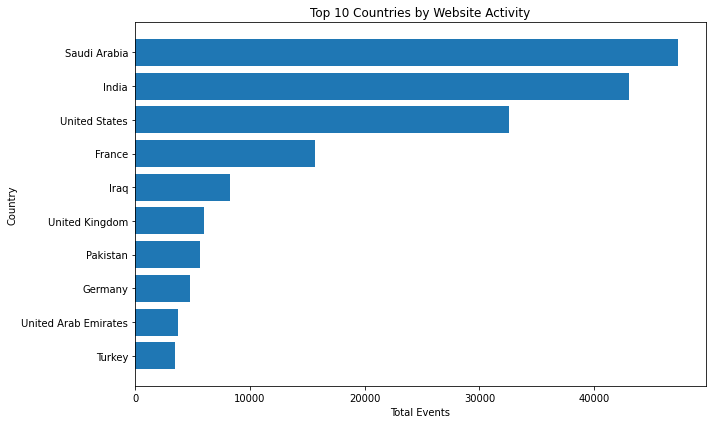

In [12]:
top_countries = country_summary.head(10).sort_values("Total_Events")

plt.figure(figsize=(10, 6))

plt.barh(
    top_countries.index,
    top_countries["Total_Events"]
)

plt.title("Top 10 Countries by Website Activity")
plt.xlabel("Total Events")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

##  Content and Link Performance

The `linkid` field is used to identify content links and evaluate which content receives the highest level of recorded activity.

In [13]:
link_summary = (
    df.groupby("linkid")
    .agg(
        Total_Events=("event", "size"),
        Pageviews=("event", lambda x: (x == "pageview").sum()),
        Clicks=("event", lambda x: (x == "click").sum()),
        Previews=("event", lambda x: (x == "preview").sum()),
        Artist=("artist", "first"),
        Track=("track", "first"),
        Album=("album", "first")
    )
    .sort_values("Total_Events", ascending=False)
)

display(link_summary.head(10))

,Total_Events,Pageviews,Clicks,Previews,Artist,Track,Album
linkid,,,,,,,
2d896d31-97b6-4869-967b-1c5fb9cd4bb8,40841,25175,9692,5974,Tesher,Jalebi Baby,Jalebi Baby
522da5cc-8177-4140-97a7-a84fdb4caf1c,10314,6600,2109,1605,Anne-Marie,Beautiful,Beautiful
e849515b-929d-44c8-a505-e7622f1827e9,9750,5981,2198,1571,Tundra Beats,Beautiful Day,Beautiful Day
c2c876ab-b093-4750-9449-6b4913da6af3,6733,4303,1429,1001,"Surf Mesa, Emilee",ily (i love you baby) (feat. Emilee),ily (i love you baby) (feat. Emilee)
681d888a-59ce-4acb-b7c5-95dab0c063d9,5512,3354,1500,658,"DMNDS, Strange Fruits Music, Fallen Roses, Lujavo, Nito-...",Calabria (feat. Lujavo & Nito-Onna),Calabria (feat. Lujavo & Nito-Onna)
23199824-9cf5-4b98-942a-34965c3b0cc2,5437,3532,1187,718,Reyanna Maria,So Pretty,So Pretty
97105aff-3e40-4c2e-bfeb-563b55e8f5dd,5367,3407,1111,849,"50 Cent, Olivia",Candy Shop,The Massacre
d5317591-872a-487d-87cb-10a516643d5f,5352,3299,1353,700,"Shawn Mendes, Tainy",Summer of Love (Shawn Mendes & Tainy),Summer Of Love
a82e72d8-523f-43ab-9fd0-992605d54b4e,5036,3039,1364,633,Roddy Ricch,Late At Night,Late At Night


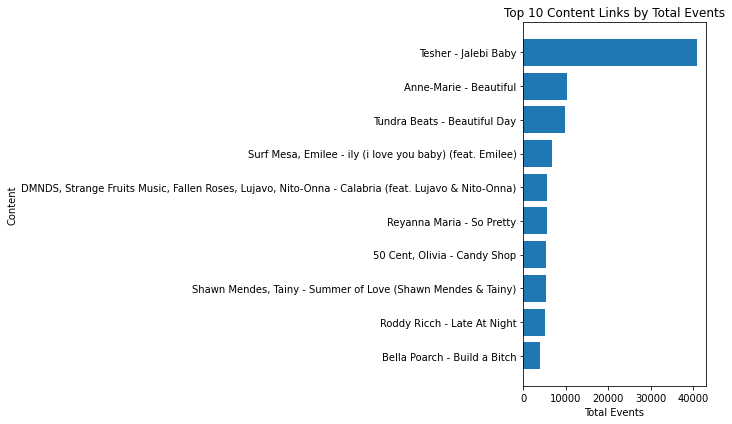

In [14]:
top_content = link_summary.head(10).sort_values("Total_Events")

labels = (
    top_content["Artist"].astype(str)
    + " - "
    + top_content["Track"].astype(str)
)

plt.figure(figsize=(10, 6))

plt.barh(
    labels,
    top_content["Total_Events"]
)

plt.title("Top 10 Content Links by Total Events")
plt.xlabel("Total Events")
plt.ylabel("Content")
plt.tight_layout()
plt.show()

##  Artist and Track Performance

In [15]:
artist_summary = (
    df.groupby("artist")
    .size()
    .sort_values(ascending=False)
)

track_summary = (
    df.groupby("track")
    .size()
    .sort_values(ascending=False)
)

print("Top 10 Artists:")
display(artist_summary.head(10).to_frame("Total Events"))

print("Top 10 Tracks:")
display(track_summary.head(10).to_frame("Total Events"))

Top 10 Artists:


,Total Events
artist,
Tesher,40841
Anne-Marie,10650
Tundra Beats,9751
"Surf Mesa, Emilee",7533
"DMNDS, Strange Fruits Music, Fallen Roses, Lujavo, Nito-Onna",5512
Reyanna Maria,5437
"Shawn Mendes, Tainy",5409
"50 Cent, Olivia",5367
Roddy Ricch,5093


Top 10 Tracks:


,Total Events
track,
Jalebi Baby,40841
Beautiful,10658
Beautiful Day,9751
ily (i love you baby) (feat. Emilee),7533
So Pretty,5664
Calabria (feat. Lujavo & Nito-Onna),5512
Summer of Love (Shawn Mendes & Tainy),5409
Candy Shop,5375
Late At Night,5036


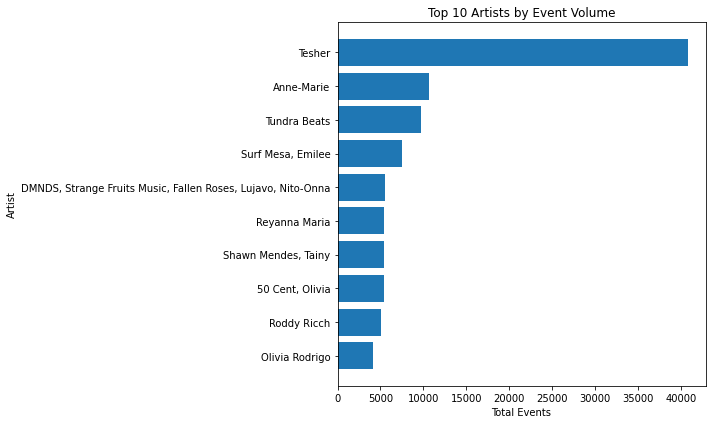

In [16]:
top_artists = artist_summary.head(10).sort_values()

plt.figure(figsize=(10, 6))

plt.barh(
    top_artists.index.astype(str),
    top_artists.values
)

plt.title("Top 10 Artists by Event Volume")
plt.xlabel("Total Events")
plt.ylabel("Artist")
plt.tight_layout()
plt.show()

##  Engagement Analysis

Since user and session identifiers are unavailable, engagement is measured at the event level using clicks and previews relative to total recorded events.

In [17]:
link_engagement = link_summary.copy()

link_engagement["Engagement_Rate"] = (
    (link_engagement["Clicks"] + link_engagement["Previews"])
    / link_engagement["Total_Events"]
)

# Avoid ranking content with extremely small samples
MIN_EVENTS = 100

high_engagement = (
    link_engagement[
        link_engagement["Total_Events"] >= MIN_EVENTS
    ]
    .sort_values("Engagement_Rate", ascending=False)
    .head(10)
)

display(
    high_engagement[
        [
            "Total_Events",
            "Pageviews",
            "Clicks",
            "Previews",
            "Engagement_Rate",
            "Artist",
            "Track"
        ]
    ].round(4)
)

,Total_Events,Pageviews,Clicks,Previews,Engagement_Rate,Artist,Track
linkid,,,,,,,
c95f1fc1-fab0-4c74-b3f5-52bd3684a713,933,10,923,0,0.9893,Sidhu Moose Wala,Akhian
ffd3c9e7-c5c5-4f28-b03d-cbaec33f2152,207,110,97,0,0.4686,Sahir Ali Bagga,Pakistan Zindabad
08bc2f1c-5c52-4616-acbd-de4e7a62c7bc,105,57,39,9,0.4571,Laica,love u lately
5d1efb00-a2af-45ce-89ab-fdbaf932c71a,168,95,44,29,0.4345,"Justin Quiles, Maluma",La Botella
35573248-4e49-47c7-af80-08a960fa74cd,229,130,69,30,0.4323,"Simone & Simaria, Sebastian Yatra",No Llores Más
b8be9e55-c2cc-4988-8921-469abff8c891,105,60,26,19,0.4286,No Spirit,feels like flying
52762e40-cb7a-4a8a-beb7-03fbd6cca9f8,764,438,250,76,0.4267,Sueco,Paralyzed
37797237-a393-45b3-ac83-49c863cb78d8,162,93,41,28,0.4259,Xilo,Aesthetic
c40647a1-b717-439b-a3c5-0f23ab4402ea,207,120,58,29,0.4203,"Vandelux, Alex Maher",Matter of Time (feat. Alex Maher)


##  Session and User-Level Analysis Limitation

The internship task requests sessions, users, bounce rate, average session duration, referral sources, user journeys, entry pages, and exit pages.

These metrics cannot be reliably calculated from the supplied dataset because it does not contain user IDs, session IDs, event timestamps, page URLs, referral sources, or conversion events.

Therefore, this project focuses on the event-level, temporal, geographic, content, and engagement metrics supported by the available data rather than creating unsupported assumptions.

##  Key Insights

- The dataset contains 226,278 recorded events across pageviews, clicks, and previews.
- Pageviews are the most common event type.
- The event-level engagement rate is approximately 37.24%.
- Saudi Arabia records the highest activity, followed by India and the United States.
- The highest traffic day is 19 August 2021, while the lowest is 23 August 2021.
- Tesher is the highest-volume artist and Jalebi Baby is the highest-volume track.
- The dataset contains a large number of exact duplicate rows, which is an important data-quality consideration.
- User-level metrics such as sessions, users, bounce rate, and session duration cannot be reliably calculated from the available fields.

##  Business Recommendations

### 1. Prioritize High-Performing Content
Promote high-volume and high-engagement content in prominent website positions.

### 2. Focus on High-Activity Markets
Consider localized campaigns and content strategies for major markets such as Saudi Arabia, India, and the United States.

### 3. Improve Content Recommendations
Use popular artists and tracks to encourage users to explore more content.

### 4. Improve Website Tracking
Add user IDs, session IDs, timestamps, page URLs, referral sources, and conversion events to enable deeper website analysis.

### 5. Conduct A/B Testing
Test page layouts, calls-to-action, content placement, and recommendation strategies to identify changes that improve engagement and conversions.

##  Conclusion

The analysis identified important patterns in website activity, geographic distribution, daily traffic, and content performance. High-performing markets and content can be used to guide future marketing and website optimization strategies.

However, the current dataset does not support reliable user-level or session-level metrics. Better tracking information would allow future analysis of user journeys, bounce rate, session duration, referrals, and conversions.